--> IMPORTING NECESSARY MODULES


In [1]:
from graph import workflow
from vectorstoresetup import load_vectorstore_with_model,load_vectorstore
from prompts import unknown_aspect_prompt
import asyncio


c:\Users\Somu\OneDrive\Desktop\Batch 60\batch 60 code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model from local path: ./models/BGE_large_EN_v1.5


c:\Users\Somu\OneDrive\Desktop\Batch 60\batch 60 code\modelsetup.py:27: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  model = HuggingFaceEmbeddings(model_name=local_model_path,encode_kwargs={"normalize_embeddings":True})
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3841.46it/s]


Loading model from local path: ./models/BGE_large_EN_v1.5


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5028.15it/s]
c:\Users\Somu\OneDrive\Desktop\Batch 60\batch 60 code\vectorstoresetup.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore=Chroma(embedding_function=embedding_model,collection_name="unknown_aspects_collection",persist_directory="./vectorstore")


In [2]:
import importlib
import clusteringworkflow
importlib.reload(clusteringworkflow)
from clusteringworkflow import label_clusters,clustering

In [3]:
import os
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

--> GRAPH

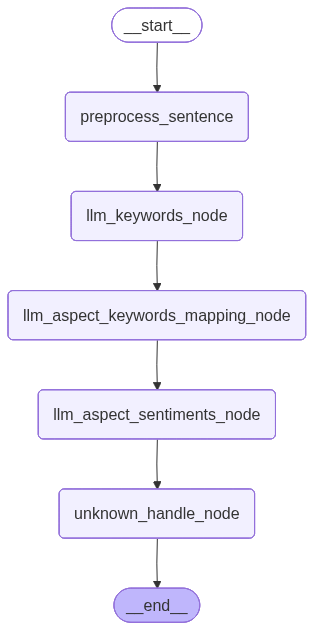

In [4]:

workflow

--> LOAD VECTORSTORE

In [5]:
vs=load_vectorstore()
vs_model=load_vectorstore_with_model()

Loading model from local path: ./models/BGE_large_EN_v1.5


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5770.41it/s]


In [6]:
vs._collection.delete(vs.get()['ids'])  #causion here 

{'deleted': 9}

--> DISPLAY RESULT FUNCTION

In [7]:
def display_result(r):

    print(f"id: {r['id']}\n")
    print(f"sentence: {r['sentence']}\n")
    print(f"finalkeywords: {r['keywords'].keywords}\n")
    print(f"mapping: {r['aspect_keywords_mapping'].aspectKeywords}\n")
    print(f"sentiments: {r['aspect_sentiments'].aspectSentiments}\n")
    print(f"unknownids: {r['unknown_ids']}")

--> SAMPLE DATA 

In [8]:
data = [
    ["1", "The steak was delicious but my iPhone battery died halfway through the meal."],
    ["2", "Service was a bit slow, although the new Samsung camera takes incredible night photos."],
    ["3", "Loved the pasta! By the way, the refresh rate on this mobile screen is so smooth."],
    ["4", "Great atmosphere, but the 5G connectivity on my phone was dropping inside the building."],
    ["5", "The dessert was too sweet. On a side note, the fast charging on this device is a lifesaver."],
    ["6", "The pizza crust was perfect. I just wish this smartphone didn't overheat so much while recording."],
    ["7", "Staff were very friendly. I'm also impressed by the face unlock speed on my new handset."],
    ["8", "Wait time for a table was long, but the water resistance on my phone saved it from a drink spill."],
    ["9", "Delicious wine selection! Also, the haptic feedback on this mobile keyboard feels very premium."],
    ["10", "The salad was fresh. However, the software updates on this android phone are quite buggy."]
]


--> MAIN FLOW AND SAVE RESULTS

In [9]:
import pandas as pd

results_list = []
for i in data:
    id, sentence = i[0], i[1]
    
    try:
        # Attempt to process the sentence
        result = await workflow.ainvoke({"id": id, "sentence": sentence, 'unknown_ids': []})
        display_result(result)
        
        # Extract Keywords as a raw list
        keywords = result['keywords'].keywords if hasattr(result['keywords'], 'keywords') else result['keywords']
        
        # Extract Mapping as a raw dictionary
        mapping = result['aspect_keywords_mapping'].aspectKeywords if hasattr(result['aspect_keywords_mapping'], 'aspectKeywords') else result['aspect_keywords_mapping']
        
        # Extract Sentiments and convert Pydantic models to a list of dicts
        sentiments_raw = result['aspect_sentiments'].aspectSentiments if hasattr(result['aspect_sentiments'], 'aspectSentiments') else result['aspect_sentiments']
        if isinstance(sentiments_raw, list):
            sentiments = []
            for s in sentiments_raw:
                if hasattr(s, 'model_dump'):
                    sentiments.append(s.model_dump())
                elif hasattr(s, 'dict'):
                    sentiments.append(s.dict())
                elif hasattr(s, '__dict__'):
                    sentiments.append(vars(s))
                else:
                    sentiments.append(s)
        else:
            sentiments = sentiments_raw

        results_list.append({
            "id": id,
            "sentence": sentence,
            "keywords": keywords,
            "mapping": mapping,
            "sentiment": sentiments
        })

    except Exception as e:
        # If processing fails, record the error for this ID
        print(f"Error processing id {id}: {e}")
        results_list.append({
            "id": id,
            "sentence": sentence,
            "keywords": f"ERROR: {str(e)}",
            "mapping": "ERROR",
            "sentiment": "ERROR"
        })

# Convert to DataFrame and save to CSV
df_results = pd.DataFrame(results_list)
output_file = os.path.join(OUTPUT_DIR, "results.csv")
df_results.to_csv(output_file, index=False)
print(f"\nWorkflow results saved to {output_file}")
df_results.head()


emojis presented: [] and its associated names: []
preprocessing node done.....
llm keywords node done.....
llm aspect keywords mapping node done.....
llm aspect sentiments node done.....
unknown content in sentences ids ['1']

unknown handle node done.....
id: 1

sentence: The steak was delicious but my iPhone battery died halfway through the meal.

finalkeywords: ['steak', 'iPhone', 'battery', 'meal', 'delicious', 'died', 'halfway', '.']

mapping: {'restaurant#food#quality': ['steak', 'delicious'], 'restaurant#other': ['meal'], 'unknown': ['iPhone', 'battery', 'died', 'halfway', '.']}

sentiments: [PrimaryOutput(target='steak', category='restaurant#food#quality', sentiment='positive'), PrimaryOutput(target='iPhone battery', category='unknown', sentiment='negative')]

unknownids: ['1']
emojis presented: [] and its associated names: []
preprocessing node done.....
llm keywords node done.....
llm aspect keywords mapping node done.....
llm aspect sentiments node done.....
unknown content 

,id,sentence,keywords,mapping,sentiment
0,1,The steak was delicious but my iPhone battery ...,"[steak, iPhone, battery, meal, delicious, died...","{'restaurant#food#quality': ['steak', 'delicio...","[{'target': 'steak', 'category': 'restaurant#f..."
1,2,"Service was a bit slow, although the new Samsu...","[Service, bit, slow, new, camera, incredible, ...","{'restaurant#service': ['Service', 'slow'], 'u...","[{'target': 'Service', 'category': 'restaurant..."
2,3,"Loved the pasta! By the way, the refresh rate ...","[pasta, way, rate, Loved, !, ,, refresh, mobil...","{'restaurant#food#quality': ['pasta', 'Loved']...","[{'target': 'pasta', 'category': 'restaurant#f..."
3,4,"Great atmosphere, but the 5G connectivity on m...",ERROR: Expected metadata list value for key 's...,ERROR,ERROR
4,5,"The dessert was too sweet. On a side note, the...","[dessert, sweet, side, fast, device, lifesaver...","{'restaurant#food#quality': ['dessert', 'sweet...","[{'target': 'dessert', 'category': 'restaurant..."


--> UPDATED VECTORSTORE

In [10]:
vs.get()['ids']

['1', '2', '3', '5', '6', '7', '8', '9', '10']

--> CLUSTERING ANALYSIS


In [11]:
clustering()


--- Clustering Results with Contextual Embeddings ---

🔹 Cluster 0:
 - Aspect: ['iPhone', 'battery', 'died', 'halfway', '.'] | Sentence: The steak was delicious but my iPhone battery died halfway through the meal.
 - Aspect: ['side', 'fast', 'device', 'lifesaver', '.', 'note', ',', 'charging'] | Sentence: The dessert was too sweet. On a side note, the fast charging on this device is a lifesaver.
 - Aspect: ['water', 'resistance', 'phone', 'spill', ',', 'saved', 'drink', '.'] | Sentence: Wait time for a table was long, but the water resistance on my phone saved it from a drink spill.

🔹 Cluster 1:
 - Aspect: ['bit', 'new', 'camera', 'incredible', 'night', 'photos', ',', 'although', 'Samsung', 'takes', '.'] | Sentence: Service was a bit slow, although the new Samsung camera takes incredible night photos.
 - Aspect: ['way', 'rate', '!', ',', 'refresh', 'mobile', 'screen', 'smooth', '.'] | Sentence: Loved the pasta! By the way, the refresh rate on this mobile screen is so smooth.
 - Aspec

In [12]:
labels=label_clusters()


--- Generating Semantic Labels (Handling Implicit Targets) ---
Cluster 0: Mobile Device Hardware
Cluster 1: Smartphone Hardware & Software

Labeled results saved to outputs\labeled_clustering_results.csv
